# Classification — Balanced Dataset (1:1 Undersampling)

Same models as Phase 6, but trained on a **perfectly balanced dataset** — equal number of samples per class.

- Positive class (suicidal ideation): ~18,750 samples
- Negative class (no ideation): ~18,750 samples (randomly undersampled)
- Total training samples: ~30,000 (vs 125,000 in the original)

This removes the class imbalance problem entirely and gives a cleaner view of model performance.


## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, average_precision_score,
                              precision_recall_curve, f1_score, recall_score,
                              precision_score, accuracy_score, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv('HMS_clean.csv', low_memory=False)

for col in ['gad7_total','loneliness','flourishing','low_income','housing_insecure',
            'food_worry','sib_any','ther_any','meds_any','inst_public','inst_size',
            'yr_sch','sui_idea']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['is_woman']     = (df['gender'] == 'Woman').astype(float)
df['is_nonbinary'] = (df['gender'] == 'Non-binary').astype(float)

FEATURES = {
    'gad7_total':       'Anxiety (GAD-7)',
    'loneliness':       'Loneliness',
    'flourishing':      'Flourishing',
    'low_income':       'Low Income',
    'housing_insecure': 'Housing Insecurity',
    'food_worry':       'Food Insecurity',
    'sib_any':          'Self-Injury',
    'ther_any':         'In Therapy',
    'meds_any':         'On Medication',
    'inst_public':      'Public Institution',
    'inst_size':        'Institution Size',
    'yr_sch':           'Year in School',
    'is_woman':         'Woman',
    'is_nonbinary':     'Non-binary',
}
feat_cols = list(FEATURES.keys())
TARGET = 'sui_idea'

ml_df = df[feat_cols + [TARGET]].dropna()
X_all = ml_df[feat_cols].values
y_all = ml_df[TARGET].values.astype(int)

print(f"Full dataset: {len(ml_df):,} samples  ({y_all.mean()*100:.1f}% positive)")


Full dataset: 152,283 samples  (11.9% positive)


## 1. Create Balanced Dataset (1:1 Undersampling)

In [2]:
rng = np.random.RandomState(42)

pos_idx = np.where(y_all == 1)[0]
neg_idx = np.where(y_all == 0)[0]

# Sample exactly as many negatives as positives
neg_sampled = rng.choice(neg_idx, size=len(pos_idx), replace=False)
balanced_idx = np.concatenate([pos_idx, neg_sampled])
rng.shuffle(balanced_idx)

X_bal = X_all[balanced_idx]
y_bal = y_all[balanced_idx]

print(f"Balanced dataset: {len(X_bal):,} samples")
print(f"  Positive (suicidal ideation): {y_bal.sum():,} ({y_bal.mean()*100:.1f}%)")
print(f"  Negative (no ideation):       {(1-y_bal).sum():,} ({(1-y_bal).mean()*100:.1f}%)")

# Train/test split — stratified to keep 50/50 in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal)

print(f"\nTrain: {len(X_train):,}  |  Test: {len(X_test):,}")
print(f"Train positive: {y_train.mean()*100:.1f}%  |  Test positive: {y_test.mean()*100:.1f}%")


Balanced dataset: 36,314 samples
  Positive (suicidal ideation): 18,157 (50.0%)
  Negative (no ideation):       18,157 (50.0%)

Train: 29,051  |  Test: 7,263
Train positive: 50.0%  |  Test positive: 50.0%


## 2. Train Models

In [3]:
# Logistic Regression (no class_weight needed — already balanced)
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(max_iter=1000, random_state=42, C=1.0))
])
lr_pipe.fit(X_train, y_train)
print("Logistic Regression trained.")

# Random Forest
rf_clf = RandomForestClassifier(
    n_estimators=300, max_depth=12, min_samples_leaf=20,
    random_state=42, n_jobs=-1
)
rf_clf.fit(X_train, y_train)
print("Random Forest trained.")


Logistic Regression trained.
Random Forest trained.


## 3. Classification Reports

In [4]:
for name, model in [('Logistic Regression', lr_pipe), ('Random Forest', rf_clf)]:
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    print(f"{'='*60}")
    print(f"{name}")
    print(f"{'='*60}")
    print(classification_report(y_test, y_pred,
                                 target_names=['No Ideation','Suicidal Ideation']))
    print(f"ROC-AUC:       {roc_auc_score(y_test, y_prob):.4f}")
    print(f"Avg Precision: {average_precision_score(y_test, y_prob):.4f}")
    print(f"Accuracy:      {accuracy_score(y_test, y_pred):.4f}")
    print()


Logistic Regression
                   precision    recall  f1-score   support

      No Ideation       0.77      0.78      0.77      3632
Suicidal Ideation       0.77      0.77      0.77      3631

         accuracy                           0.77      7263
        macro avg       0.77      0.77      0.77      7263
     weighted avg       0.77      0.77      0.77      7263

ROC-AUC:       0.8514
Avg Precision: 0.8335
Accuracy:      0.7735

Random Forest
                   precision    recall  f1-score   support

      No Ideation       0.79      0.75      0.77      3632
Suicidal Ideation       0.76      0.80      0.78      3631

         accuracy                           0.77      7263
        macro avg       0.77      0.77      0.77      7263
     weighted avg       0.77      0.77      0.77      7263

ROC-AUC:       0.8526
Avg Precision: 0.8343
Accuracy:      0.7731



## 4. Confusion Matrices

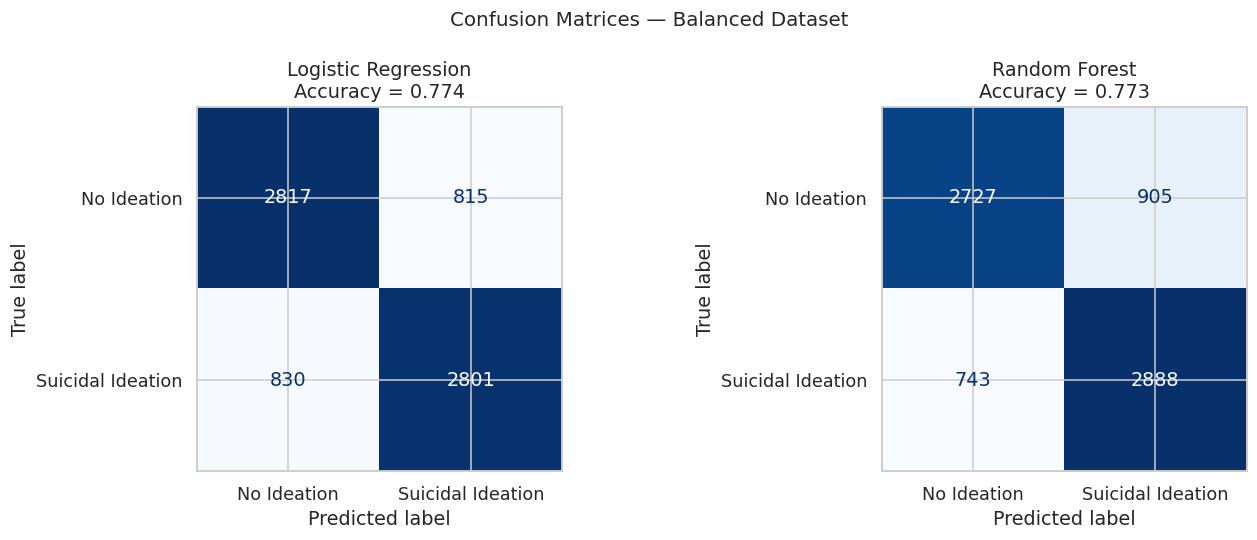

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (name, model) in zip(axes, [('Logistic Regression', lr_pipe),
                                      ('Random Forest', rf_clf)]):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Ideation','Suicidal Ideation'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    acc = accuracy_score(y_test, y_pred)
    ax.set_title(f'{name}\nAccuracy = {acc:.3f}')
plt.suptitle('Confusion Matrices — Balanced Dataset', fontsize=13)
plt.tight_layout(); plt.show()


## 5. ROC & Precision-Recall Curves

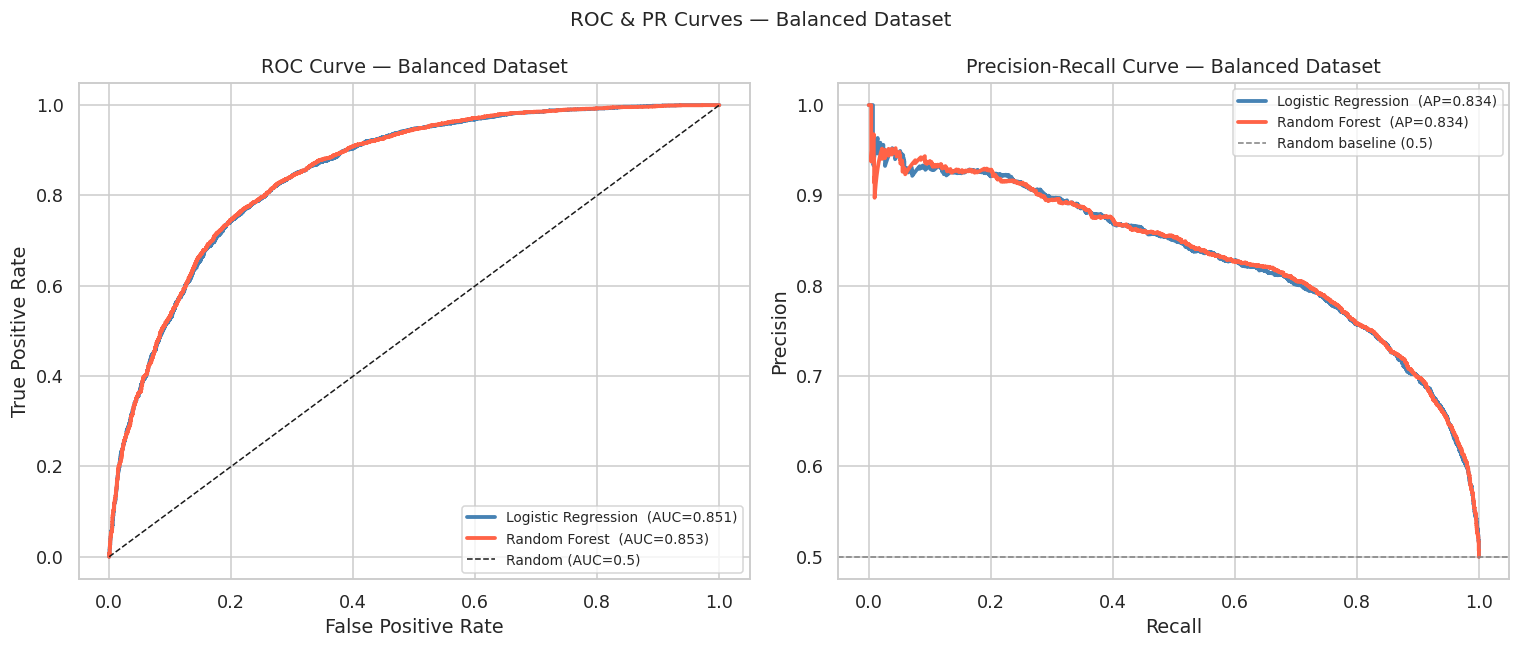

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC
for (name, model), color in zip([('Logistic Regression', lr_pipe),
                                   ('Random Forest', rf_clf)],
                                  ['steelblue','tomato']):
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, color=color, lw=2.5, label=f'{name}  (AUC={auc:.3f})')

axes[0].plot([0,1],[0,1],'k--',lw=1,label='Random (AUC=0.5)')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Balanced Dataset')
axes[0].legend(fontsize=9)

# PR
for (name, model), color in zip([('Logistic Regression', lr_pipe),
                                   ('Random Forest', rf_clf)],
                                  ['steelblue','tomato']):
    y_prob = model.predict_proba(X_test)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    axes[1].plot(rec, prec, color=color, lw=2.5, label=f'{name}  (AP={ap:.3f})')

axes[1].axhline(0.5, color='gray', linestyle='--', lw=1, label='Random baseline (0.5)')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve — Balanced Dataset')
axes[1].legend(fontsize=9)

plt.suptitle('ROC & PR Curves — Balanced Dataset', fontsize=13)
plt.tight_layout(); plt.show()


## 6. Training vs Validation Accuracy Curves

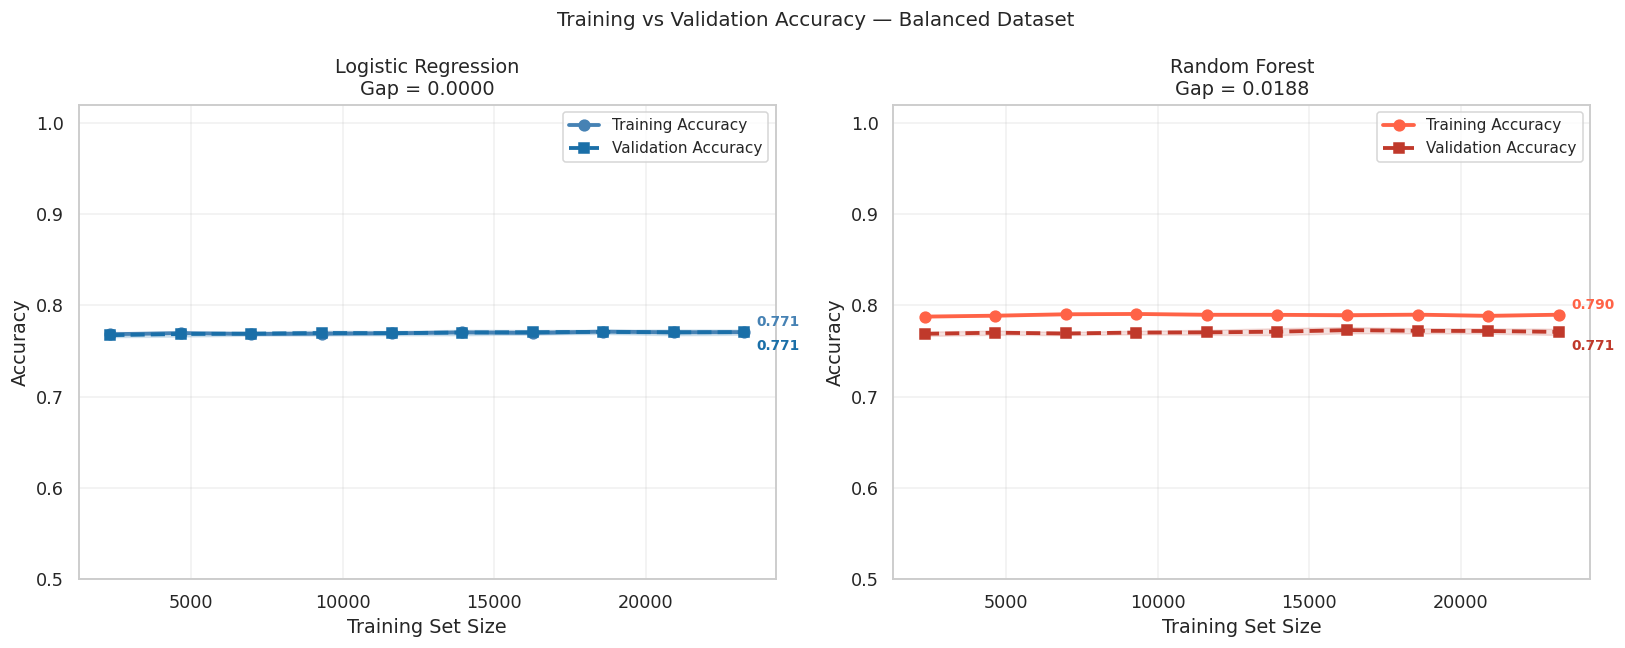

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, (name, model), c_train, c_val in zip(
    axes,
    [('Logistic Regression', lr_pipe), ('Random Forest', rf_clf)],
    ['steelblue','tomato'], ['#1a6fa8','#c0392b']
):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train, y_train,
        train_sizes=np.linspace(0.1, 1.0, 10),
        cv=5, scoring='accuracy', n_jobs=-1, random_state=42
    )
    tm = train_scores.mean(axis=1); ts = train_scores.std(axis=1)
    vm = val_scores.mean(axis=1);   vs = val_scores.std(axis=1)

    ax.plot(train_sizes, tm, 'o-', color=c_train, lw=2.5, markersize=7, label='Training Accuracy')
    ax.fill_between(train_sizes, tm-ts, tm+ts, alpha=0.15, color=c_train)
    ax.plot(train_sizes, vm, 's--', color=c_val,   lw=2.5, markersize=7, label='Validation Accuracy')
    ax.fill_between(train_sizes, vm-vs, vm+vs, alpha=0.15, color=c_val)

    ax.annotate(f'{tm[-1]:.3f}', (train_sizes[-1], tm[-1]),
                textcoords='offset points', xytext=(8,4), fontsize=9,
                color=c_train, fontweight='bold')
    ax.annotate(f'{vm[-1]:.3f}', (train_sizes[-1], vm[-1]),
                textcoords='offset points', xytext=(8,-12), fontsize=9,
                color=c_val, fontweight='bold')

    ax.set_xlabel('Training Set Size'); ax.set_ylabel('Accuracy')
    ax.set_title(f'{name}\nGap = {tm[-1]-vm[-1]:.4f}')
    ax.legend(fontsize=10); ax.set_ylim(0.5, 1.02); ax.grid(alpha=0.3)

plt.suptitle('Training vs Validation Accuracy — Balanced Dataset', fontsize=13)
plt.tight_layout(); plt.show()


## 7. Feature Importance

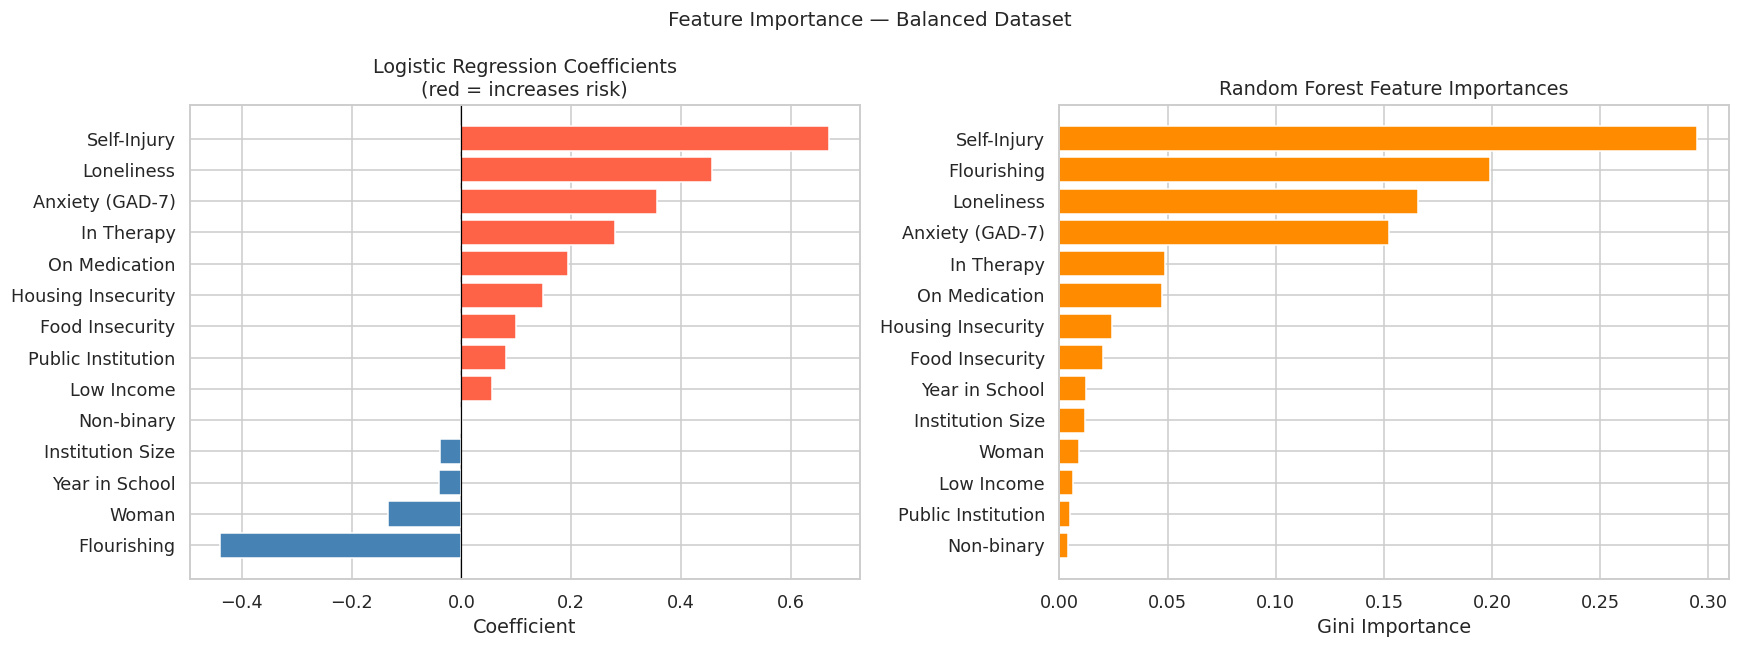

In [8]:
feat_names = list(FEATURES.values())
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# LR coefficients
lr_coefs = lr_pipe.named_steps['clf'].coef_[0]
coef_df  = pd.DataFrame({'feature': feat_names, 'coef': lr_coefs}).sort_values('coef')
colors_lr = ['tomato' if c > 0 else 'steelblue' for c in coef_df['coef']]
axes[0].barh(coef_df['feature'], coef_df['coef'], color=colors_lr, edgecolor='white')
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_title('Logistic Regression Coefficients\n(red = increases risk)')
axes[0].set_xlabel('Coefficient')

# RF importances
rf_imp = pd.DataFrame({'feature': feat_names,
                        'importance': rf_clf.feature_importances_}).sort_values('importance')
axes[1].barh(rf_imp['feature'], rf_imp['importance'], color='darkorange', edgecolor='white')
axes[1].set_title('Random Forest Feature Importances')
axes[1].set_xlabel('Gini Importance')

plt.suptitle('Feature Importance — Balanced Dataset', fontsize=13)
plt.tight_layout(); plt.show()


## 8. Cross-Validation Summary

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("5-Fold Cross-Validation on Balanced Training Set:")
print("-" * 50)
for name, model in [('Logistic Regression', lr_pipe), ('Random Forest', rf_clf)]:
    for metric, scoring in [('Accuracy','accuracy'), ('AUC','roc_auc'), ('F1','f1')]:
        scores = cross_val_score(model, X_train, y_train,
                                  cv=cv, scoring=scoring, n_jobs=-1)
        print(f"  {name:25s} {metric:10s}: {scores.mean():.4f} ± {scores.std():.4f}")
    print()


5-Fold Cross-Validation on Balanced Training Set:
--------------------------------------------------
  Logistic Regression       Accuracy  : 0.7704 ± 0.0044
  Logistic Regression       AUC       : 0.8511 ± 0.0032
  Logistic Regression       F1        : 0.7710 ± 0.0044

  Random Forest             Accuracy  : 0.7718 ± 0.0058
  Random Forest             AUC       : 0.8515 ± 0.0028
  Random Forest             F1        : 0.7777 ± 0.0059



## 10. Model Comparison — All Metrics

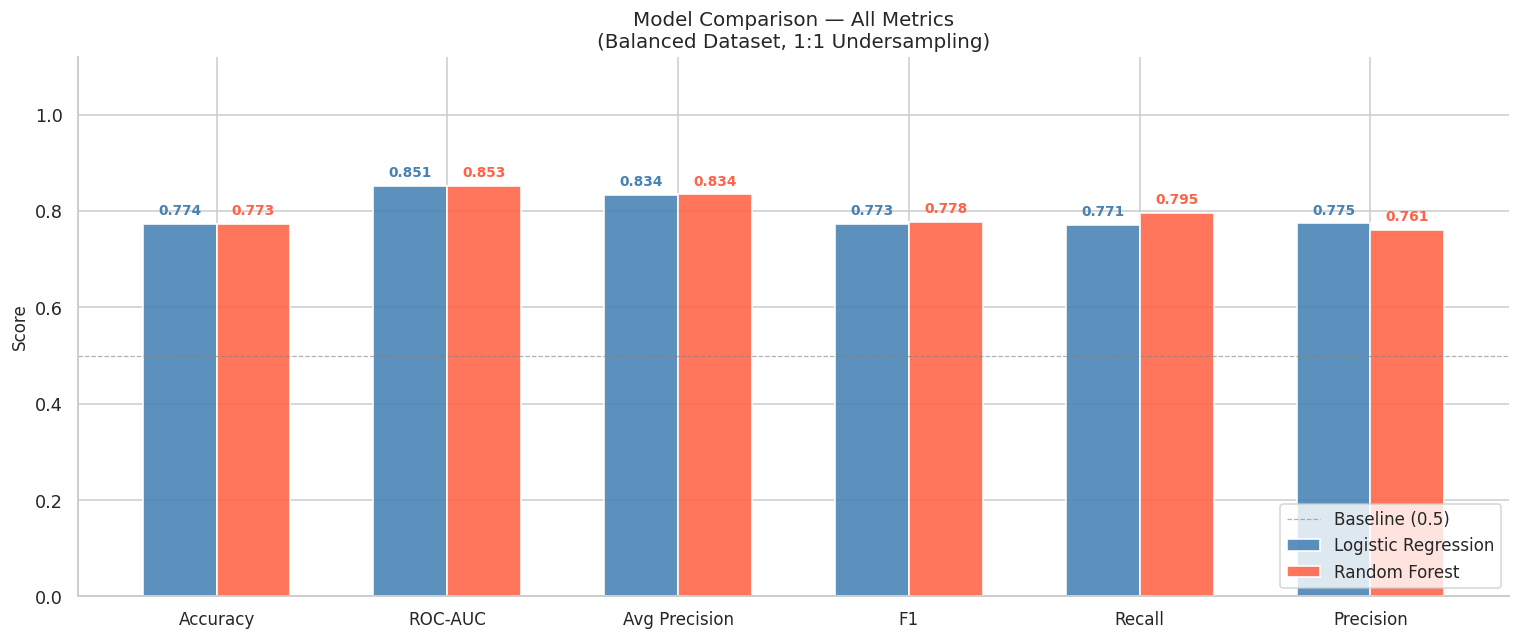

Metric               Logistic Regression         Random Forest
--------------------------------------------------------------
Accuracy                          0.7735                0.7731
ROC-AUC                           0.8514                0.8526
Avg Precision                     0.8335                0.8343
F1                                0.7730                0.7780
Recall                            0.7714                0.7954
Precision                         0.7746                0.7614


In [10]:
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score,
                              recall_score, precision_score, average_precision_score)

models = [('Logistic Regression', lr_pipe), ('Random Forest', rf_clf)]
metric_names = ['Accuracy', 'ROC-AUC', 'Avg Precision', 'F1', 'Recall', 'Precision']

results = {}
for name, model in models:
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    results[name] = [
        accuracy_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob),
        average_precision_score(y_test, y_prob),
        f1_score(y_test, y_pred, pos_label=1),
        recall_score(y_test, y_pred, pos_label=1),
        precision_score(y_test, y_pred, pos_label=1),
    ]

# ── Figure ────────────────────────────────────────────────────────────────
n_metrics = len(metric_names)
x = np.arange(n_metrics)
w = 0.32
colors = ['steelblue', 'tomato']

fig, ax = plt.subplots(figsize=(14, 6))

for i, (name, vals) in enumerate(results.items()):
    offset = (i - (len(models)-1)/2) * w
    bars = ax.bar(x + offset, vals, w,
                  label=name, color=colors[i],
                  alpha=0.88, edgecolor='white', linewidth=1.2)
    for bar, val in zip(bars, vals):
        ax.annotate(f'{val:.3f}',
                    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 4), textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=9, fontweight='bold', color=colors[i])

# Reference line at 0.5
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.6, label='Baseline (0.5)')

ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_title('Model Comparison — All Metrics\n(Balanced Dataset, 1:1 Undersampling)',
             fontsize=13)
ax.legend(fontsize=11, loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Print table
print(f"{'Metric':<18}", end='')
for name in results: print(f"{name:>22}", end='')
print()
print("-" * 62)
for i, metric in enumerate(metric_names):
    print(f"{metric:<18}", end='')
    for name in results:
        print(f"{results[name][i]:>22.4f}", end='')
    print()


## 9. Summary — Balanced vs Original

In [11]:
print("COMPARISON: Original (imbalanced) vs Balanced (1:1)")
print("=" * 65)
print(f"{'Metric':<20} {'Original LR':>14} {'Balanced LR':>14}")
print("-" * 50)
print(f"{'Training size':<20} {'125,090':>14} {len(X_train):>14,}")
print(f"{'Positive rate':<20} {'12%':>14} {'50%':>14}")
print()

y_pred_bal = lr_pipe.predict(X_test)
y_prob_bal = lr_pipe.predict_proba(X_test)[:, 1]

metrics = [
    ('Accuracy',  accuracy_score(y_test, y_pred_bal)),
    ('AUC',       roc_auc_score(y_test, y_prob_bal)),
    ('F1 (pos)',  f1_score(y_test, y_pred_bal, pos_label=1)),
    ('Recall',    recall_score(y_test, y_pred_bal, pos_label=1)),
    ('Precision', precision_score(y_test, y_pred_bal, pos_label=1)),
]
original = [0.76, 0.8475, 0.44, 0.77, 0.31]  # from phase 6

for (name, bal_val), orig_val in zip(metrics, original):
    delta = bal_val - orig_val
    arrow = '↑' if delta > 0 else '↓'
    print(f"  {name:<18}: orig={orig_val:.3f}  balanced={bal_val:.3f}  {arrow}{abs(delta):.3f}")


COMPARISON: Original (imbalanced) vs Balanced (1:1)
Metric                  Original LR    Balanced LR
--------------------------------------------------
Training size               125,090         29,051
Positive rate                   12%            50%

  Accuracy          : orig=0.760  balanced=0.774  ↑0.014
  AUC               : orig=0.848  balanced=0.851  ↑0.004
  F1 (pos)          : orig=0.440  balanced=0.773  ↑0.333
  Recall            : orig=0.770  balanced=0.771  ↑0.001
  Precision         : orig=0.310  balanced=0.775  ↑0.465
